In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
import re
from wordcloud import WordCloud
from collections import Counter


In [3]:
# mac의 경우
plt.rcParams['font.family'] = 'AppleGothic'

In [4]:
# NLTK stopwords 다운로드 (최초 1회)
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/wonjong-u/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
df = pd.read_csv("../data/twice_korean_singles_lines.csv")

In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # 문자/공백 외 제거
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [7]:
custom_stopwords = set([
    "oh", "yeah", "na", "nana", "ah", "ooh", "woo",
    "ha", "la", "nan", "geu", "meon", "neo", "ne",
    "neomu", "jjit", "hae", "geol", "geoya"
])

stop_words = set(stopwords.words('english')) | custom_stopwords

In [8]:
song_groups = df.groupby("song_name")

song_word_freq = {}  # 곡별 단어 빈도 저장

for song, group in song_groups:
    lyrics = " ".join(group["lyric"].astype(str))
    lyrics = clean_text(lyrics)
    
    words = lyrics.split()
    words = [w for w in words if w not in stop_words and len(w) > 1]  # 필터링

    freq = Counter(words)
    song_word_freq[song] = freq

In [9]:
def plot_wordcloud(song, freq):
    save_name = song
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(freq)
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"WordCloud - {song}")
    save_path = f"images/wordcloud/{save_name}_wordcloud.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

In [10]:
def plot_bar(song, freq, top_n=15):
    save_name = song
    top_words = freq.most_common(top_n)
    words = [w for w, _ in top_words]
    counts = [c for _, c in top_words]

    plt.figure(figsize=(10, 5))
    plt.bar(words, counts)
    plt.xticks(rotation=45)
    plt.title(f"Top {top_n} Words - {song}")
    save_path = f"images/bar/{save_name}_bar.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

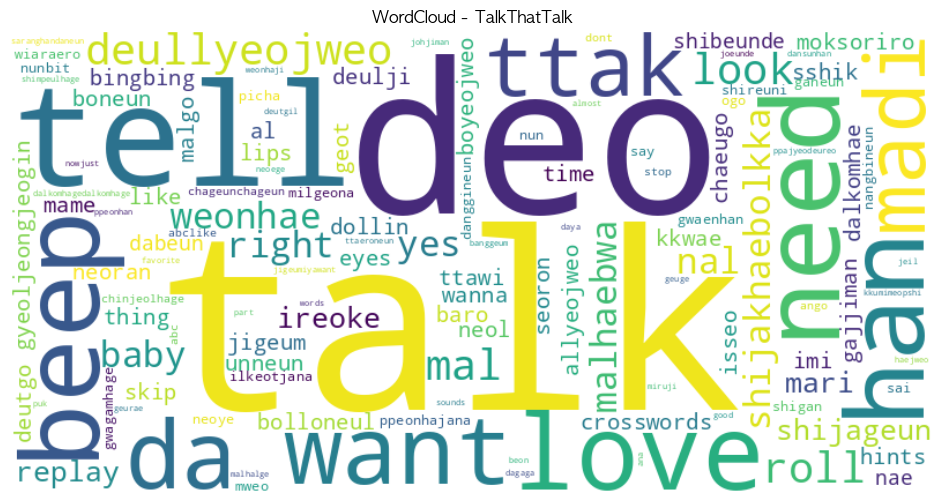

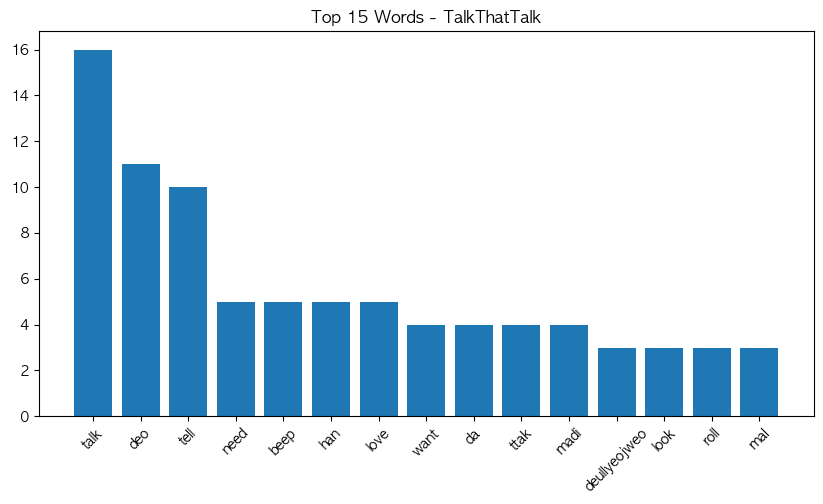

In [11]:
song = "TalkThatTalk"
freq = song_word_freq[song]

plot_wordcloud(song, freq)
plot_bar(song, freq)